In [1]:
%pip install matplotlib seaborn plotly


Note: you may need to restart the kernel to use updated packages.


# Customer Personality Prediction
**Life cycle of Machine learning Project**

* Understanding the Problem Statement
* Data Collection
* Data Cleaning
* Exploratory data analysis
* Data Pre-Processing
* Model Training 
* Choose best model

## 1) Problem statement.

* **xyz** company wants to enable and establish a viable business model to expand the customer base. 
* One of the ways to expand the customer base is to introduce a new offering of packages based on the customer personalities. 
* The company wants to segregate the customers so that they can release relevant offers for the respective customers

### **What is Customer personality analysis and segmentation?**

Customer Personality Analysis is a detailed analysis of a company’s ideal customers. It helps a business to better understand its customers and makes it easier for them to modify products according to the specific needs, behaviors and concerns of different types of customers.

Customer personality analysis helps a business to modify its product based on its target customers from different types of customer segments. For example, instead of spending money to market a new product to every customer in the company’s database, a company can analyze which customer segment is most likely to buy the product and then market the product only on that particular segment.


## 2. Data Collection
- The dataset is downloaded from https://github.com/entbappy/Branching-tutorial/blob/master/marketing_campaign.zip

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")



import the reqquired liberaires that will be used is exploration of data

import the dataset by copying its relative path using pandas

In [3]:
df = pd.read_csv("marketing_campaign.csv", sep="\t")# if you dont use \t data wont be in proper format

In [4]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
df.dtypes

ID                       int64
Year_Birth               int64
Education                  str
Marital_Status             str
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer                str
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

In [6]:
df.shape

(2240, 29)

In [7]:
df.sample()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
1665,6437,1985,2n Cycle,Single,41473.0,1,0,19-06-2013,80,21,...,7,0,0,0,0,0,0,3,11,0


In [8]:
#display statistics of numerical columns or even stat summary of all columns
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [9]:
df.info()#will give dtypes and null values as well and the count of th enull values in each column

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

CONVERTING CUSTOMER DATETIME INTO PANDAS DT FORMAT

In [10]:
#conversion into date time format
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format="%d-%m-%Y")

In [11]:
df.dtypes

ID                              int64
Year_Birth                      int64
Education                         str
Marital_Status                    str
Income                        float64
Kidhome                         int64
Teenhome                        int64
Dt_Customer            datetime64[us]
Recency                         int64
MntWines                        int64
MntFruits                       int64
MntMeatProducts                 int64
MntFishProducts                 int64
MntSweetProducts                int64
MntGoldProds                    int64
NumDealsPurchases               int64
NumWebPurchases                 int64
NumCatalogPurchases             int64
NumStorePurchases               int64
NumWebVisitsMonth               int64
AcceptedCmp3                    int64
AcceptedCmp4                    int64
AcceptedCmp5                    int64
AcceptedCmp1                    int64
AcceptedCmp2                    int64
Complain                        int64
Z_CostContac

In [12]:
df['Dt_Customer']

0      2012-09-04
1      2014-03-08
2      2013-08-21
3      2014-02-10
4      2014-01-19
          ...    
2235   2013-06-13
2236   2014-06-10
2237   2014-01-25
2238   2014-01-24
2239   2012-10-15
Name: Dt_Customer, Length: 2240, dtype: datetime64[us]

In [13]:
#defining numerical and cat columns
#dropping id
columns = [columns for columns in df.columns if columns !='ID']

numeric_features = [feature for feature in columns if df[feature].dtypes !='o']

cat_features = [feature for feature in columns if df[feature].dtypes == 'o']

#printing the features
print('we have {} numeric_features : {}'.format(len(numeric_features), numeric_features))
print('we have {} cat_features : {}'.format(len(cat_features), cat_features))

we have 28 numeric_features : ['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']
we have 0 cat_features : []


### Feature Information

- **People**

    - **ID:** Customer's unique identifier
    - **Year_Birth:** Customer's birth year
    - **Education:** Customer's education level
    - **Marital_Status:** Customer's marital status
    - **Income:** Customer's yearly household income
    - **Kidhome:** Number of children in customer's household
    - **Teenhome:** Number of teenagers in customer's household
    - **Dt_Customer:** Date of customer's enrollment with the company
    - **Recency:** Number of days since customer's last purchase
    - **Complain:** 1 if the customer complained in the last 2 years, 0 otherwise

- **Products**

    - **MntWines:** Amount spent on wine in last 2 years
    - **MntFruits:** Amount spent on fruits in last 2 years
    - **MntMeatProducts:** Amount spent on meat in last 2 years
    - **MntFishProducts:** Amount spent on fish in last 2 years
    - **MntSweetProducts:** Amount spent on sweets in last 2 years
    - **MntGoldProds:** Amount spent on gold in last 2 years

- **Promotion**

    - **NumDealsPurchases:** Number of purchases made with a discount
    - **AcceptedCmp1:** 1 if customer accepted the offer in the 1st campaign, 0 otherwise
    - **AcceptedCmp2:** 1 if customer accepted the offer in the 2nd campaign, 0 otherwise
    - **AcceptedCmp3:** 1 if customer accepted the offer in the 3rd campaign, 0 otherwise
    - **AcceptedCmp4:** 1 if customer accepted the offer in the 4th campaign, 0 otherwise
    - **AcceptedCmp5:** 1 if customer accepted the offer in the 5th campaign, 0 otherwise
    - **Response:** 1 if customer accepted the offer in the last campaign, 0 otherwise

- **Place**

    - **NumWebPurchases:** Number of purchases made through the company’s website
    - **NumCatalogPurchases:** Number of purchases made using a catalogue
    - **NumStorePurchases:** Number of purchases made directly in stores
    - **NumWebVisitsMonth:** Number of visits to company’s website in the last month
df.columns
df[categorical_features[0]].value_counts().count()
# proportion of count data on categorical columns
for col in categorical_features:
    print(df[col].value_counts(normalize=True) * 100)
    print('---------------------------')

In [14]:
numeric_features = df[columns].select_dtypes(include=['int64', 'float64']).columns.tolist()

cat_features = df[columns].select_dtypes(include=['object', 'string']).columns.tolist()

In [15]:
print('we have {} numeric_features : {}'.format(len(numeric_features), numeric_features))
print('we have {} cat_features : {}'.format(len(cat_features), cat_features))

we have 25 numeric_features : ['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']
we have 2 cat_features : ['Education', 'Marital_Status']


In [16]:
df.columns.tolist()

['ID',
 'Year_Birth',
 'Education',
 'Marital_Status',
 'Income',
 'Kidhome',
 'Teenhome',
 'Dt_Customer',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Complain',
 'Z_CostContact',
 'Z_Revenue',
 'Response']

In [17]:
df[cat_features[0]].value_counts().count()

5

In [18]:
df[cat_features[0]].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [19]:
#propertion of count of data in cat columns
for col in cat_features:
    print(df[col].value_counts(normalize=True)*100)
    print("--------------------------------------------------")

Education
Graduation    50.312500
PhD           21.696429
Master        16.517857
2n Cycle       9.062500
Basic          2.410714
Name: proportion, dtype: float64
--------------------------------------------------
Marital_Status
Married     38.571429
Together    25.892857
Single      21.428571
Divorced    10.357143
Widow        3.437500
Alone        0.133929
Absurd       0.089286
YOLO         0.089286
Name: proportion, dtype: float64
--------------------------------------------------


In [20]:
#univariant and bivariant and multivariant analysis

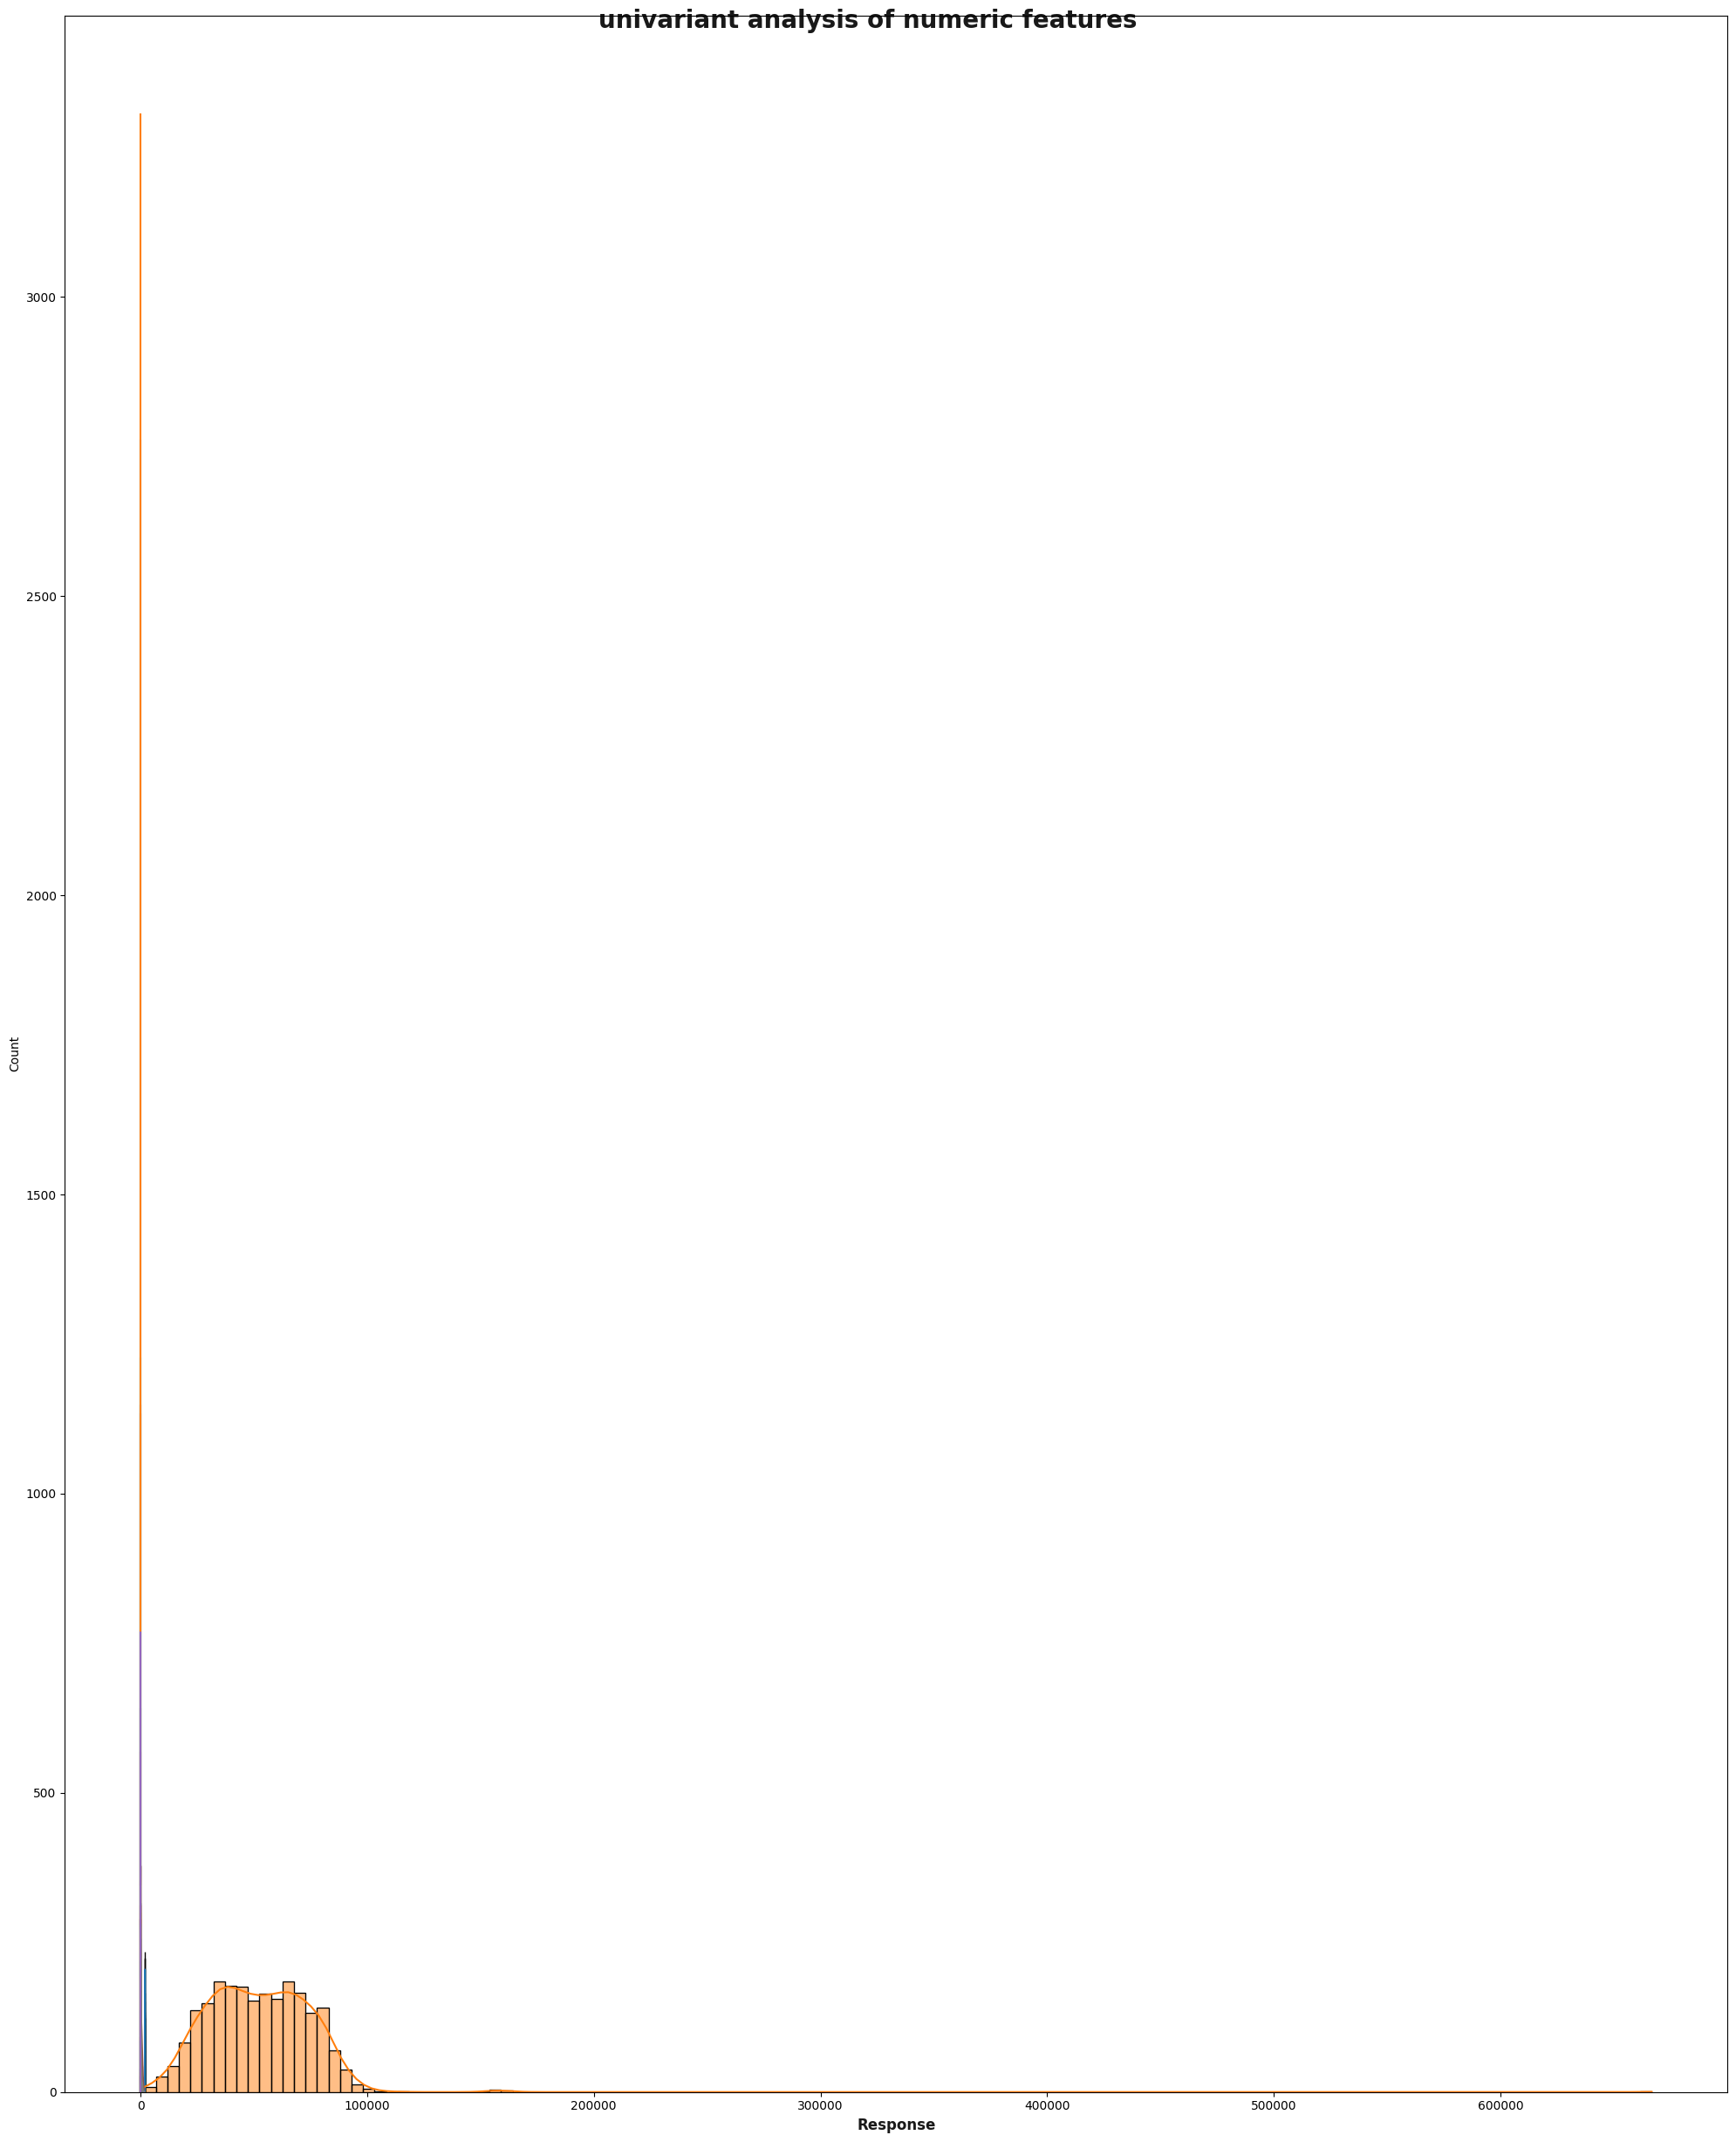

In [21]:
import math
plt.figure(figsize=(20, 25))  # Increased figsize to accommodate more subplots
plt.suptitle("univariant analysis of numeric features", fontsize=20, fontweight="bold", alpha=0.9, y=0.98)
rows = math.ceil(len(numeric_features) / 5)  # Calculate rows for 5 columns
for i in range(len(numeric_features)):
    sns.histplot(df[numeric_features[i]], kde=True)
    plt.xlabel(numeric_features[i], fontsize=12, fontweight="bold", alpha=0.9)
    plt.tight_layout()

*Report of the univariate analytis*
1. `Year_Birth` is left-skewed, most of the values falls in 1940-2000 range and has outliers.
2. `Income` is right-skewed, most of the values falls in 0 - <200000 range and has outliers.
3. `Kidhome`, `Teenhome` has constant values. Most of the values seems to be 0 or 1 and some of the values are 2.
4. `Dt_customer`, `Recency` are following a normal distribution
5. `MntWines`, `MntMeatProducts` are right-skewed, most of the values falls in 0 - 500 range and has outliers.
6. `MntFruits`, `MntFishProducts`, `MntSweetProducts`, `MntGoldProds` is right-skewed, most of the values falls in 0-50 range and has outliers.
7. `NumDealsPurchases` is right-skewed, most of the values falls in 0-5 range and has outliers.
8. `NumWebPurchases`, `NumCatalogPurchases` are right skewed and most of the values falls in 0-10 range and have outliers.
9. `NumStorePurchases` is almost following a normal distribution and most of the values falls in 1 - 10 range and has outliers.
10. `NumWebVisitsMonth` is right-skewed, most of the values falls in 0- 10 range and has outliers.
11. `AcceptedCmp3`, `AcceptedCmp4`, `AcceptedCmp5`, `AcceptedCmp1`,`AcceptedCmp2` is right skewed and most of the values are 0 and some of the values are 1.
12. `Complain` has most of the values as 0 and we can see a little bit of the values as 1. 
13. `Z_CostContact`, `Z_Revenue` columns are not showing any graph. We'll graph those seperately and check what is happening.
14. `Response` has constant values as 0 and 1. 

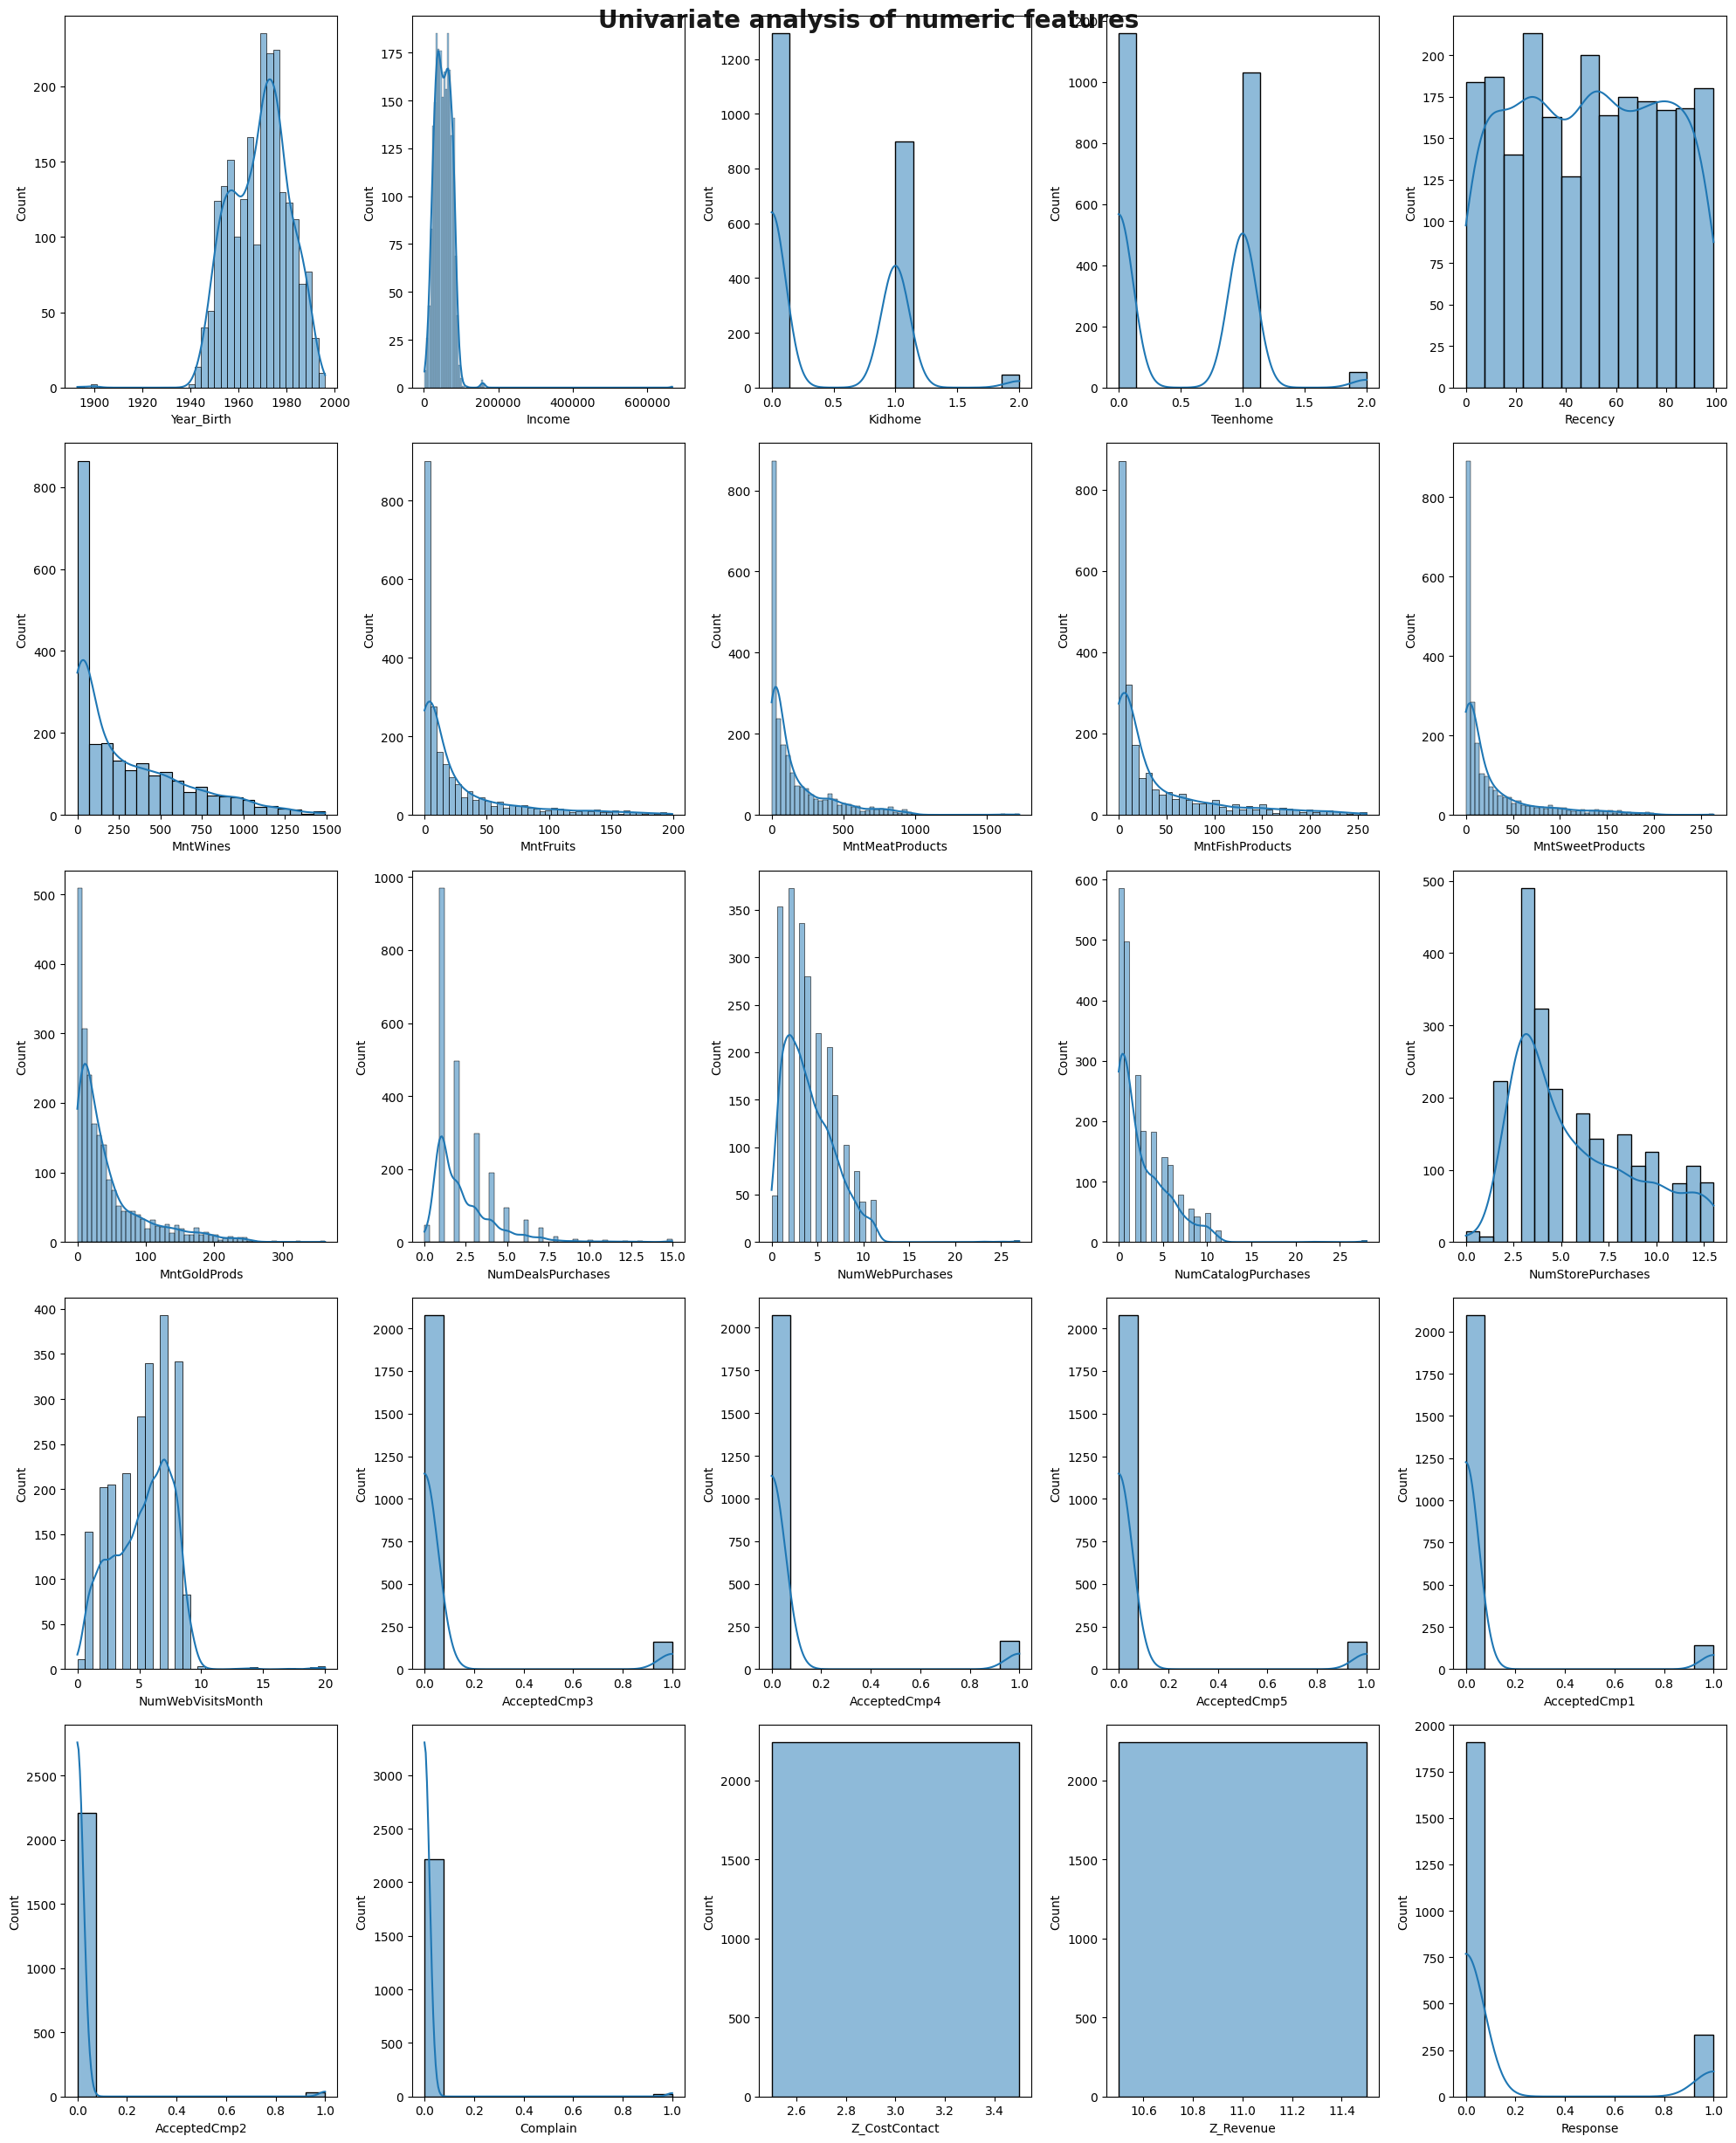

In [22]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 25))
plt.suptitle("Univariate analysis of numeric features",
             fontsize=20, fontweight="bold", alpha=0.9, y=0.98)

rows = math.ceil(len(numeric_features) / 5)

for i in range(len(numeric_features)):
    plt.subplot(rows, 5, i + 1)   # <-- THIS IS THE KEY LINE
    sns.histplot(df[numeric_features[i]], kde=True)
    plt.xlabel(numeric_features[i], fontsize=10)

plt.tight_layout()
plt.show()

<Axes: >

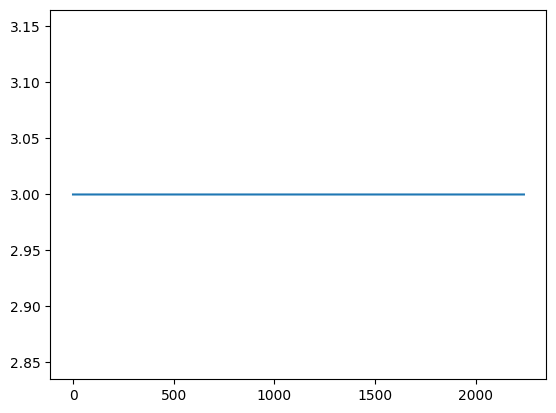

In [23]:
df.Z_CostContact.plot()#no movement in these plot so we can drop these columns

<Axes: >

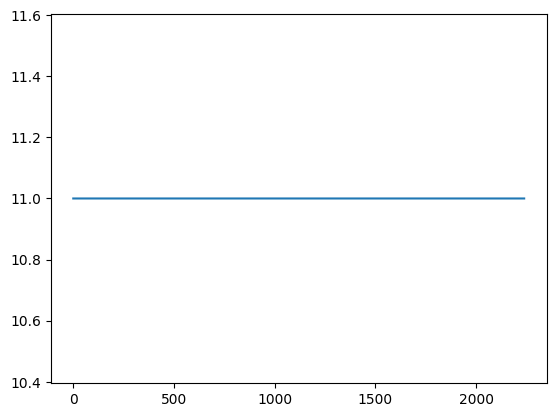

In [24]:
df.Z_Revenue.plot()#this as well has no movement so we can drop this column as well

In [25]:
df = df.drop(columns=['Z_CostContact', 'Z_Revenue'])
df.columns.tolist()

['ID',
 'Year_Birth',
 'Education',
 'Marital_Status',
 'Income',
 'Kidhome',
 'Teenhome',
 'Dt_Customer',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Complain',
 'Response']

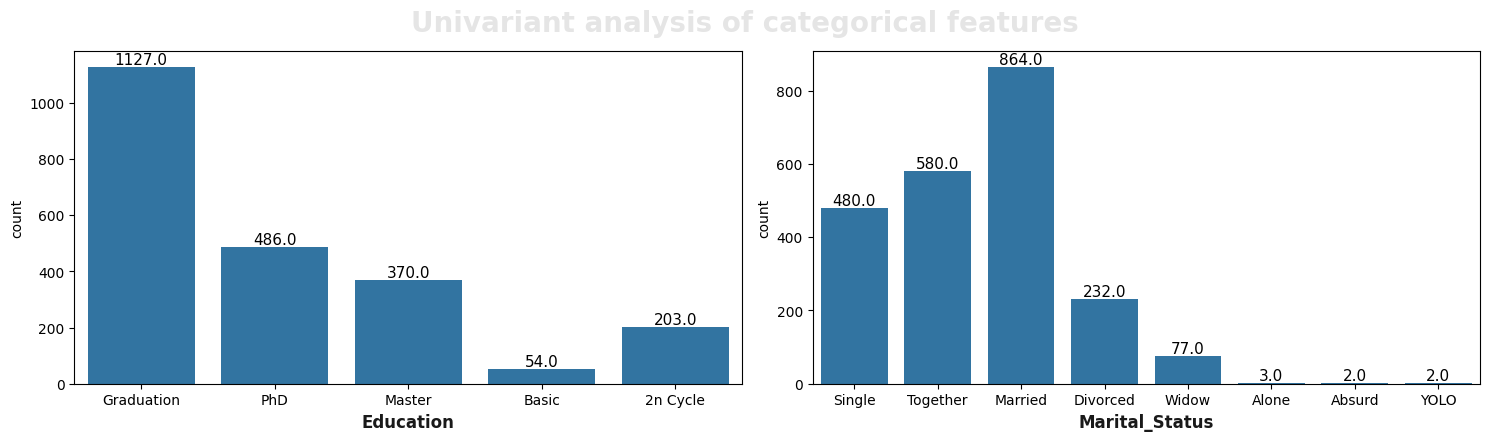

In [26]:
#categorical columns
plt.figure(figsize=(15, 8))
plt.suptitle('Univariant analysis of categorical features', fontsize=20, fontweight='bold', alpha =0.1, y=0.98)

for i in range(len(cat_features)):
    plt.subplot(2, 2, i+1)
    ax = sns.countplot(x=df[cat_features[i]])
    if df[cat_features[i]].value_counts().count() < 10:
        for p in ax.patches:
            ax.annotate( "{:.1f}". format(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
    plt.xlabel(cat_features[i], fontsize=12, fontweight='bold', alpha=0.9)
    plt.tight_layout()  




<Axes: xlabel='Year', ylabel='customer_joined'>

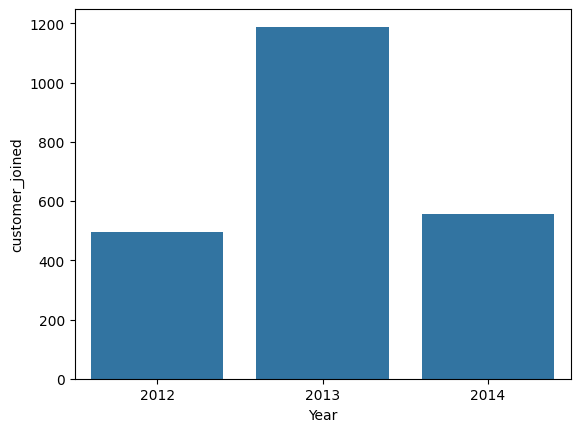

In [27]:
df1 = df.copy()
df1['Year'] = df1['Dt_Customer'].dt.year
customer_joined_per_year = df1.groupby('Year')[['ID']].count().reset_index()
customer_joined_per_year.columns = ['Year', 'customer_joined']
sns.barplot(x='Year', y='customer_joined', data=customer_joined_per_year)


<Axes: >

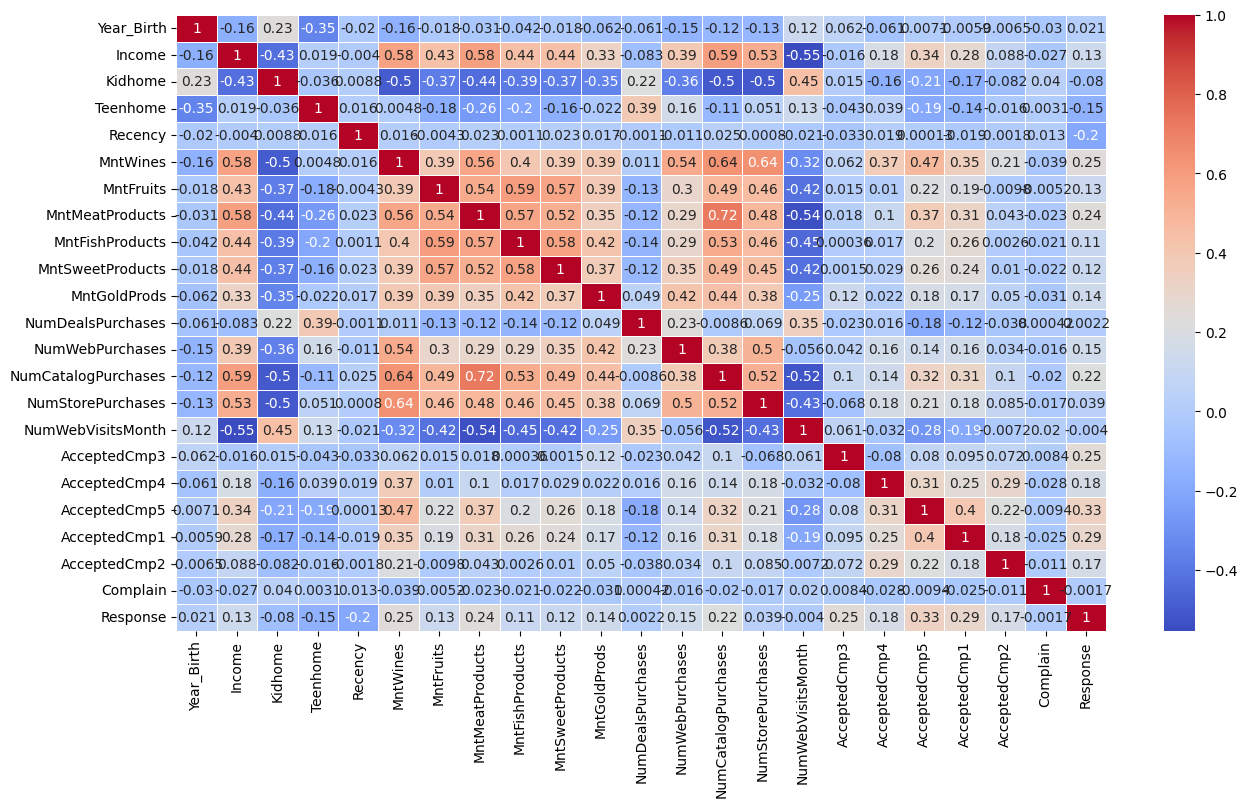

In [28]:
#now multivariant analysis
plt.figure(figsize=(15, 8))
num_features = numeric_features.copy()
num_features.remove('Z_CostContact')
num_features.remove('Z_Revenue')
sns.heatmap(df[num_features].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
#it doesnt matter if u write plt.show it will automatically show the plot in jupyter notebook but in pycharm you have to write plt.show() to show the plot



In [29]:
df.Income.isnull().sum() #earlier it was 24 but after treatemnt 

24

In [30]:
#imputuing the null values using meadian
df.Income = df.Income.fillna(df.Income.median(), inplace=True)

In [31]:
df.Income.median()#we are filling the null values with median so we are checking the median value of income column

51381.5

In [32]:
df['Marital_Status'].isnull().sum()

0

In [33]:
df['Education'].unique()
df['Marital_Status'].unique()

<ArrowStringArray>
['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone', 'Absurd',
 'YOLO']
Length: 8, dtype: str

# Feature Extraction

#### The following code creates features that would be helpful to describe the profile of the customer 

In [34]:
#Education — match exact casing from dataset
df['Education'].replace(
    {'Basic': 0, '2n Cycle': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4},
    inplace=True
)

# Marital — overwrite the SAME column, then drop original
marital_map = {
    'Single': 0, 'Married': 1, 'Divorced': 2,
    'Together': 3, 'Widow': 4, 'Unknown': 5
}
df['Marital_Status'] = df['Marital_Status'].map(marital_map).fillna(5).astype(int)

In [41]:
#feature extractions

from datetime import datetime

raw_df = df.copy()  # saving a copy of the raw dataframe

# we have the year of birth column but not the age column so we are going to create one
df['age'] = datetime.today().year - df['Year_Birth']  # 'age' is already present in df

# recording customer education level in numeric form
df['Education'].replace(
	{'Basic': 0, '2n cycle': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4},
	inplace=True
)

# now converting customer marital status to numeric form
marital_map = {
	'Single': 0,
	'Married': 1,
	'Divorced': 2,
	'Together': 3,
	'Widow': 4,
	'Unknown': 5
}
marital_col = next((col for col in ['Marital_Status', 'Marital_status'] if col in df.columns), None)
if marital_col is not None:
	df['Marital_status'] = df[marital_col].map(marital_map).fillna(5).astype(int)
else:
	df['Marital_status'] = 5
	print("Warning: no marital status column found; defaulting all rows to 5 (Unknown).")

# creating a new feature to store number of children in a household
df['no_of_children'] = raw_df['Kidhome'] + raw_df['Teenhome']

# creating family size feature
df['family_size'] = df['Marital_status'] + df['no_of_children'] + 1

# total spending of the customer
df['total_spending'] = (
	 raw_df['MntWines']
	+ raw_df['MntFruits']
	+ raw_df['MntMeatProducts']
	+ raw_df['MntFishProducts']
	+ raw_df['MntSweetProducts']
	+ raw_df['MntGoldProds']
)

# total promo accepted by customer
df['total_promo'] = raw_df[
	['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
].sum(axis=1)

# for how long the customer has been with the company
df['Dt_customer'] = pd.to_datetime(df['Dt_Customer'], format="%d-%m-%Y")
today = datetime.today()
df['Day_as_customer'] = (today - df['Dt_customer']).dt.days

df['offer_respond_to'] = (
	raw_df['AcceptedCmp1']
	+ raw_df['AcceptedCmp2']
	+ raw_df['AcceptedCmp3']
	+ raw_df['AcceptedCmp4']
	+ raw_df['AcceptedCmp5']
	+ raw_df['Response']
)

df['Parental_status'] = np.where(df['no_of_children'] > 0, 1, 0)




In [42]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response', 'Marital_status',
       'no_of_children', 'family_size', 'total_spending', 'total_promo',
       'Dt_customer', 'Day_as_customer', 'offer_respond_to', 'Parental_status',
       'age'],
      dtype='str')

In [43]:
#dropping all columns which are already used to create new features
columns_to_drop = ['Year_Birth']

# Check if columns exist before dropping to avoid KeyError
for col in columns_to_drop:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

df.rename(columns={
    "MntWines": "Wines",
    "MntFruits": "Fruits",
    "MntMeatProducts": "Meat",
    "MntFishProducts": "Fish",
    "MntSweetProducts": "Sweets",
    "MntGoldProds": "Gold",
    "NumWebPurchases": "Web",
    "NumCatalogPurchases": "Catalog",
    "NumStorePurchases": "Store",
    "NumDealsPurchases": "Discount Purchases"
}, inplace=True)

df = df[['age', 'Education', 'Marital_status', 'Income', 'Dt_Customer', 'Recency',
         'Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold',
         'Web', 'Catalog', 'Store', 'Discount Purchases',
         'total_spending', 'total_promo', 'Day_as_customer',
         'offer_respond_to', 'Parental_status']]


In [44]:
print(len(df.columns))
for i, col in enumerate(df.columns):
    print(i, repr(col))

21
0 'age'
1 'Education'
2 'Marital_status'
3 'Income'
4 'Dt_Customer'
5 'Recency'
6 'Wines'
7 'Fruits'
8 'Meat'
9 'Fish'
10 'Sweets'
11 'Gold'
12 'Web'
13 'Catalog'
14 'Store'
15 'Discount Purchases'
16 'total_spending'
17 'total_promo'
18 'Day_as_customer'
19 'offer_respond_to'
20 'Parental_status'


In [45]:
required_cols = ['age', 'Education', 'Marital_status', 'Income', 'Dt_Customer', 'Recency',
                 'Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold',
                 'Web', 'Catalog', 'Store', 'Discount Purchases',
                 'total_spending', 'total_promo', 'Day_as_customer',
                 'offer_respond_to', 'Parental_status']

missing = [col for col in required_cols if col not in df.columns]
print("Missing columns:", missing)

Missing columns: []


In [46]:
raw_df.columns.tolist()

['ID',
 'Year_Birth',
 'Education',
 'Marital_Status',
 'Income',
 'Kidhome',
 'Teenhome',
 'Dt_Customer',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Complain',
 'Response',
 'Marital_status',
 'no_of_children',
 'family_size',
 'total_spending',
 'total_promo',
 'Dt_customer',
 'Day_as_customer',
 'offer_respond_to',
 'Parental_status']

In [47]:
df.columns

Index(['age', 'Education', 'Marital_status', 'Income', 'Dt_Customer',
       'Recency', 'Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold', 'Web',
       'Catalog', 'Store', 'Discount Purchases', 'total_spending',
       'total_promo', 'Day_as_customer', 'offer_respond_to',
       'Parental_status'],
      dtype='str')

In [48]:
for col in df.columns:#u were facing an error about marital status column they looked similar whn u passed in the code and the dataset but they were actually different
    if 'Marital' in col:
        print(col, len(col))

Marital_status 14


In [49]:
print(len('Marital_Status'))

14


In [50]:
df.shape

(2240, 21)

In [51]:
columns = [column for column in df.columns if column !='ID']
numer_features = [feature for feature in columns if df[feature].dtypes !='o']
continue_features = [feature for feature in columns if df[feature].dtypes == 'o']
print('we have {} numeric_features : {}'.format(len(numer_features), numer_features))

we have 21 numeric_features : ['age', 'Education', 'Marital_status', 'Income', 'Dt_Customer', 'Recency', 'Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold', 'Web', 'Catalog', 'Store', 'Discount Purchases', 'total_spending', 'total_promo', 'Day_as_customer', 'offer_respond_to', 'Parental_status']


In [52]:
#multicolinearity check
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(considered_features, df):
    X = df[considered_features].copy()  # Use .copy() to avoid modifying the original df
    # the cal of vif requires a constant
    X['intercept'] = 1

    # creating dataframe to store vif values
    vif = pd.DataFrame()
    vif['Variables'] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif = vif[vif['Variables'] != 'intercept']  # Exclude the intercept from the results
    return vif  # Return the vif dataframe for use



#we will remove datetime columns which is not required in vif
numer_features = numer_features.copy()

#we will not check vif for total spending column as it is a combination of other columns and it will have high vif value
if 'total_spending' in numer_features:
    numer_features.remove('total_spending')  # Assuming 'Total_Spending' is the correct column name in df
if 'Dt_Customer' in numer_features:
    numer_features.remove('Dt_Customer')
compute_vif(numer_features, df)
#other columns



TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [53]:
from statsmodels.stats.outliers_influence import variance_inflation_factor



columns = [column for column in df.columns if column != 'ID']

numer_features = [feature for feature in columns if df[feature].dtype != 'object']
continue_features = [feature for feature in columns if df[feature].dtype == 'object']

print(f'we have {len(numer_features)} numeric_features : {numer_features}')
print(f'we have {len(continue_features)} categorical_features : {continue_features}')



df_vif = df.copy()

for col in continue_features:
    df_vif[col] = df_vif[col].astype('category').cat.codes




all_features = numer_features + continue_features

# remove problematic columns safely
remove_cols = ['total_spending', 'Dt_Customer']

all_features = [col for col in all_features if col in df_vif.columns and col not in remove_cols]





def compute_vif(features, df):
    X = df[features].copy()

    # safety check
    if X.shape[1] == 0:
        print("❌ No features available for VIF")
        return None

    X['intercept'] = 1

    vif = pd.DataFrame()
    vif['Variables'] = X.columns
    vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    vif = vif[vif['Variables'] != 'intercept']

    return vif




vif_df = compute_vif(all_features, df_vif)

print(vif_df)

we have 21 numeric_features : ['age', 'Education', 'Marital_status', 'Income', 'Dt_Customer', 'Recency', 'Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold', 'Web', 'Catalog', 'Store', 'Discount Purchases', 'total_spending', 'total_promo', 'Day_as_customer', 'offer_respond_to', 'Parental_status']
we have 0 categorical_features : []


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [54]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
import pandas as pd

# =========================
# STEP 1: COPY DATA
# =========================

df_vif = df.copy()

# =========================
# STEP 2: ENCODE CATEGORICAL
# =========================

cat_cols = df_vif.select_dtypes(include='object').columns

for col in cat_cols:
    df_vif[col] = df_vif[col].astype('category').cat.codes

# =========================
# STEP 3: REMOVE PROBLEMATIC COLUMNS
# =========================

drop_cols = [
    'ID',
    'Dt_Customer',          # datetime
    'Z_CostContact',        # constant
    'Z_Revenue'             # constant
]

df_vif = df_vif.drop(columns=[col for col in drop_cols if col in df_vif.columns])

# =========================
# STEP 4: HANDLE NaN & INF
# =========================

df_vif.replace([np.inf, -np.inf], np.nan, inplace=True)
df_vif.dropna(inplace=True)

# =========================
# STEP 5: VIF CALCULATION
# =========================

X = df_vif.copy()
X['intercept'] = 1

vif = pd.DataFrame()
vif['Variables'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif = vif[vif['Variables'] != 'intercept']

print(vif.sort_values(by='VIF', ascending=False))

             Variables       VIF
10                Gold       inf
5                Wines       inf
6               Fruits       inf
7                 Meat       inf
8                 Fish       inf
9               Sweets       inf
15      total_spending       inf
16         total_promo  9.196390
18    offer_respond_to  9.018420
12             Catalog  2.804659
13               Store  2.208778
3               Income  1.990606
19     Parental_status  1.896799
11                 Web  1.812793
14  Discount Purchases  1.405825
17     Day_as_customer  1.194530
1            Education  1.183341
0                  age  1.088374
4              Recency  1.062612
2       Marital_status  0.000000


In [55]:
cont_features = df[numer_features].select_dtypes(include=[np.number]).columns.tolist()
if 'total_spending' in cont_features:
    cont_features.remove('total_spending')
if 'Dt_Customer' in cont_features:
    cont_features.remove('Dt_Customer')
compute_vif(cont_features, df)

,Variables,VIF
0,age,1.072231
1,Marital_status,0.000000
2,Income,1.981976
3,Recency,1.062486
4,Wines,3.170313
5,Fruits,1.944778
6,Meat,2.973419
7,Fish,2.086972
8,Sweets,1.892976
9,Gold,1.482474


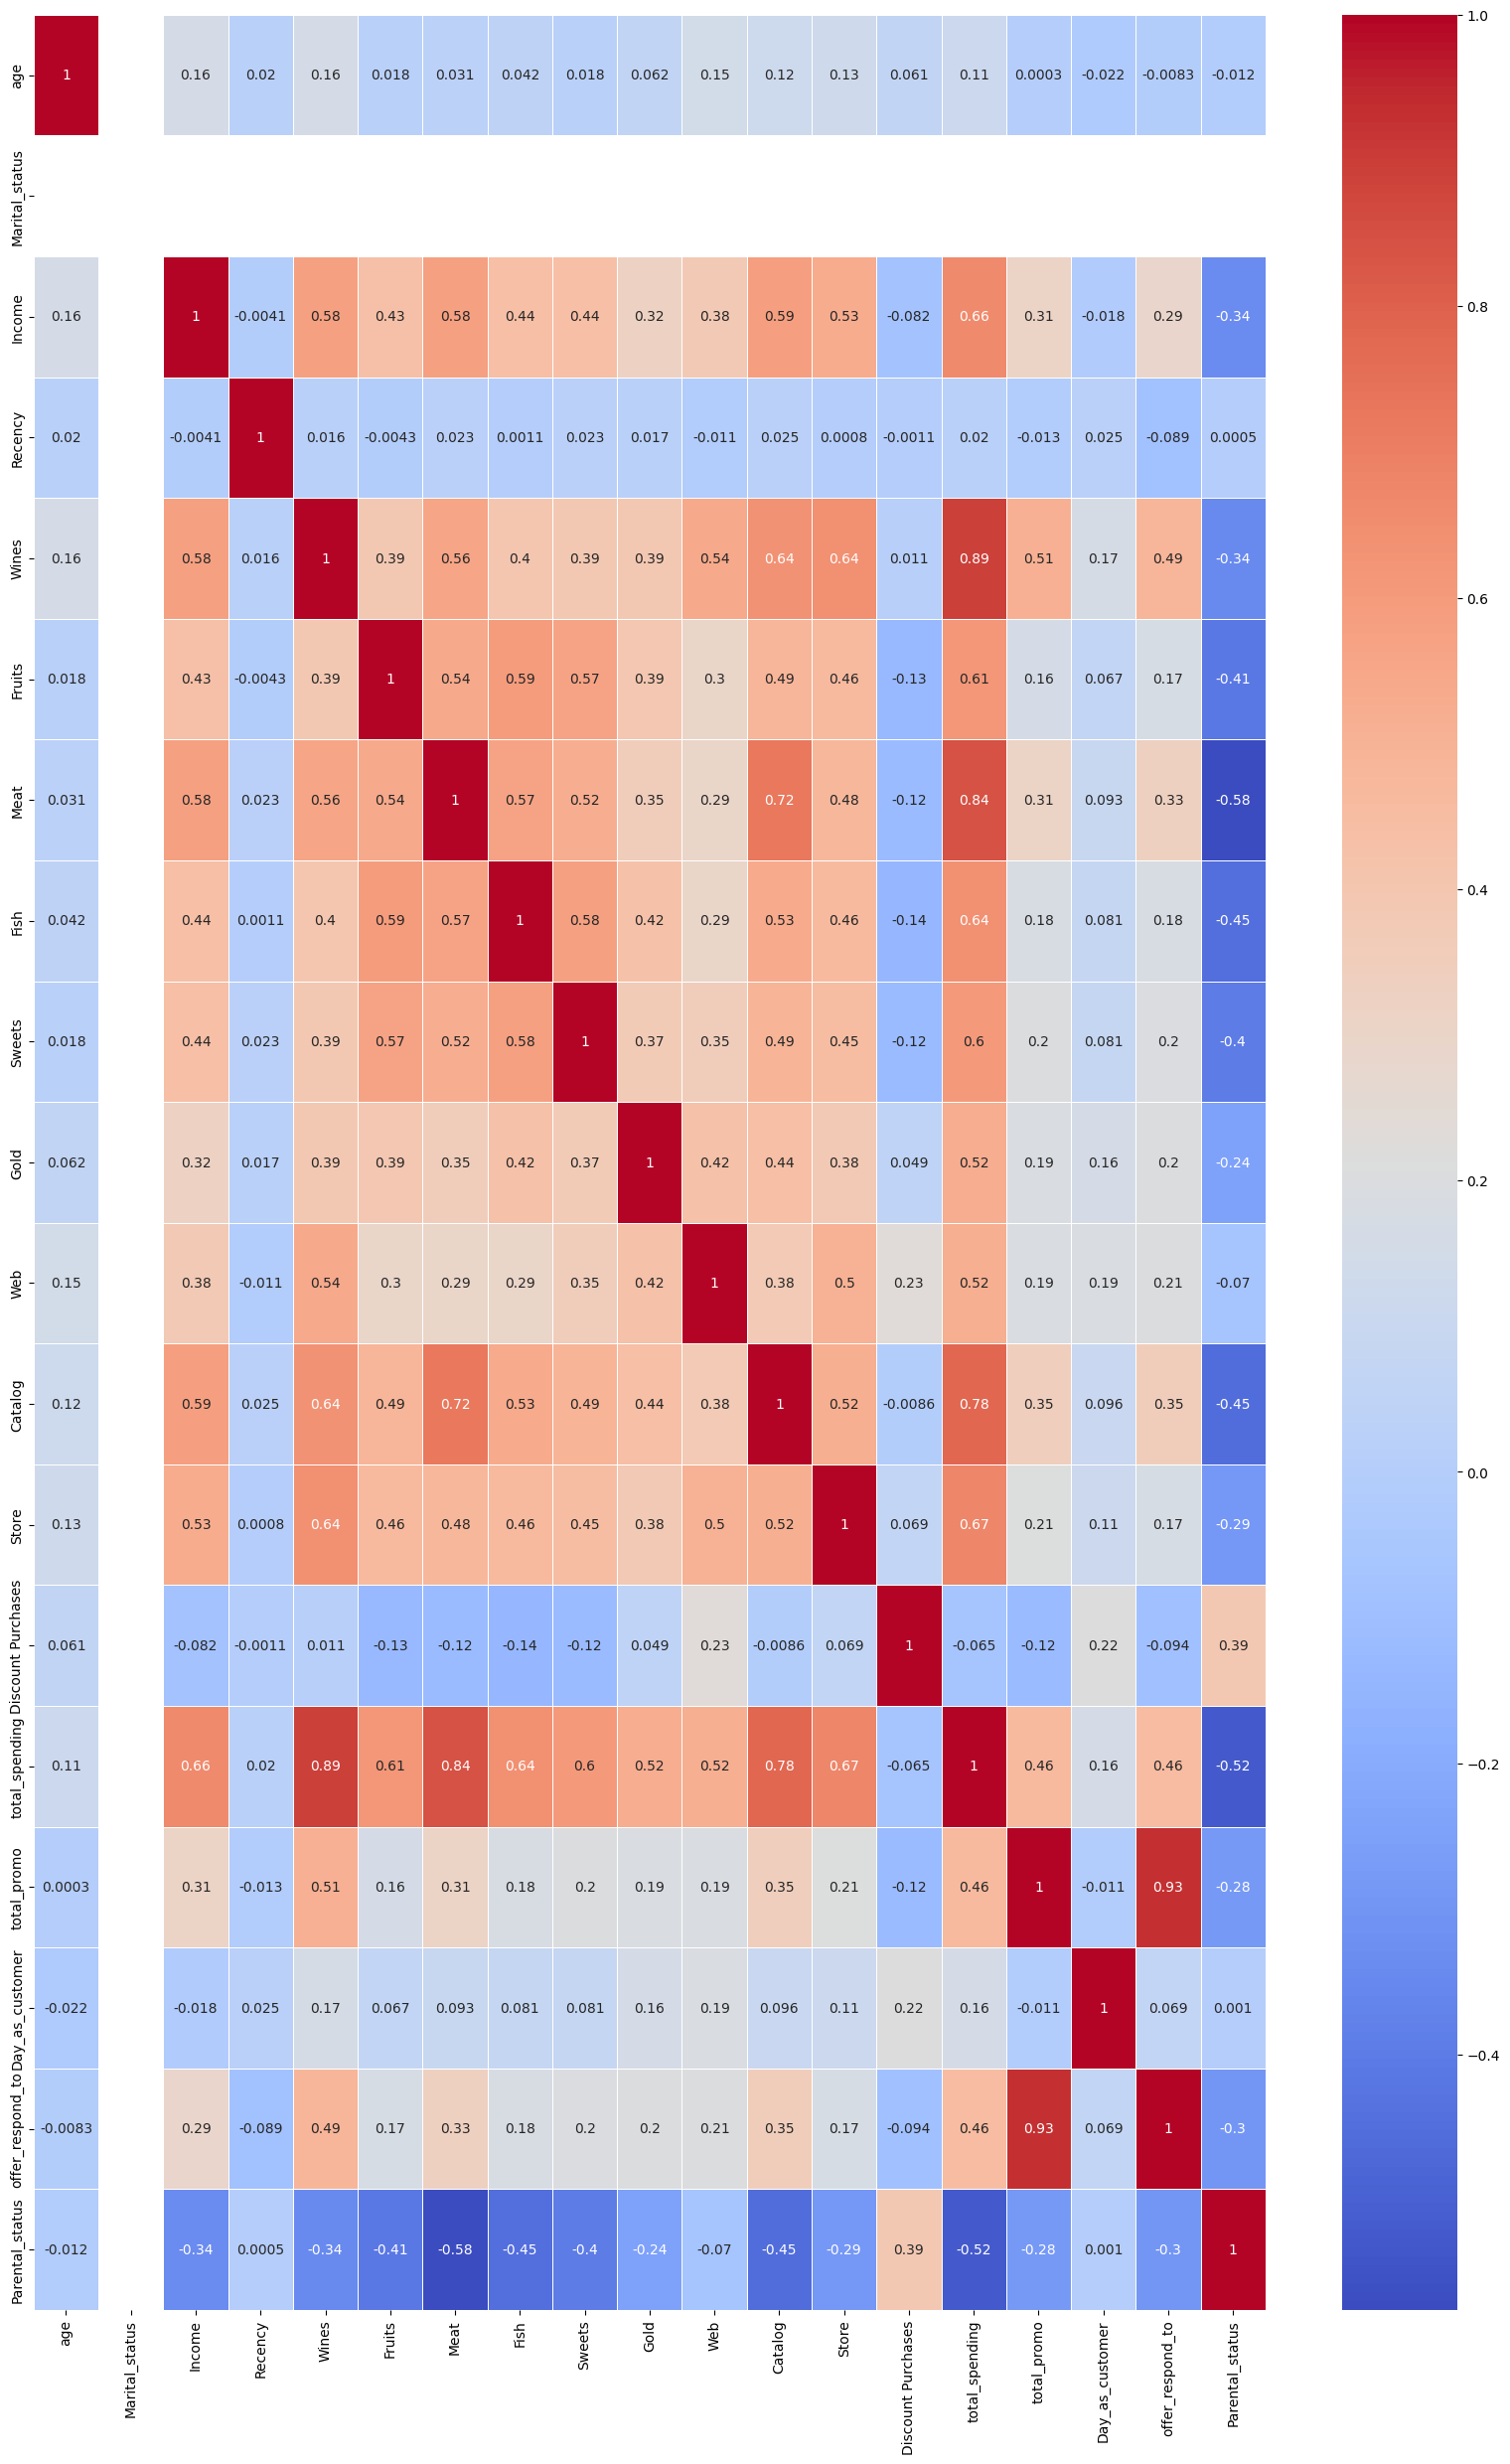

In [65]:
plt.figure(figsize=(20,30))
num_features = numer_features.copy()


sns.heatmap(df[num_features].corr(), annot=True, cmap='coolwarm',  linewidths=0.5)
plt.show()

In [57]:
df['Education'].dtypes

<StringDtype(na_value=nan)>

In [58]:
numer_features = df[numer_features].select_dtypes(include=[np.number]).columns.tolist()

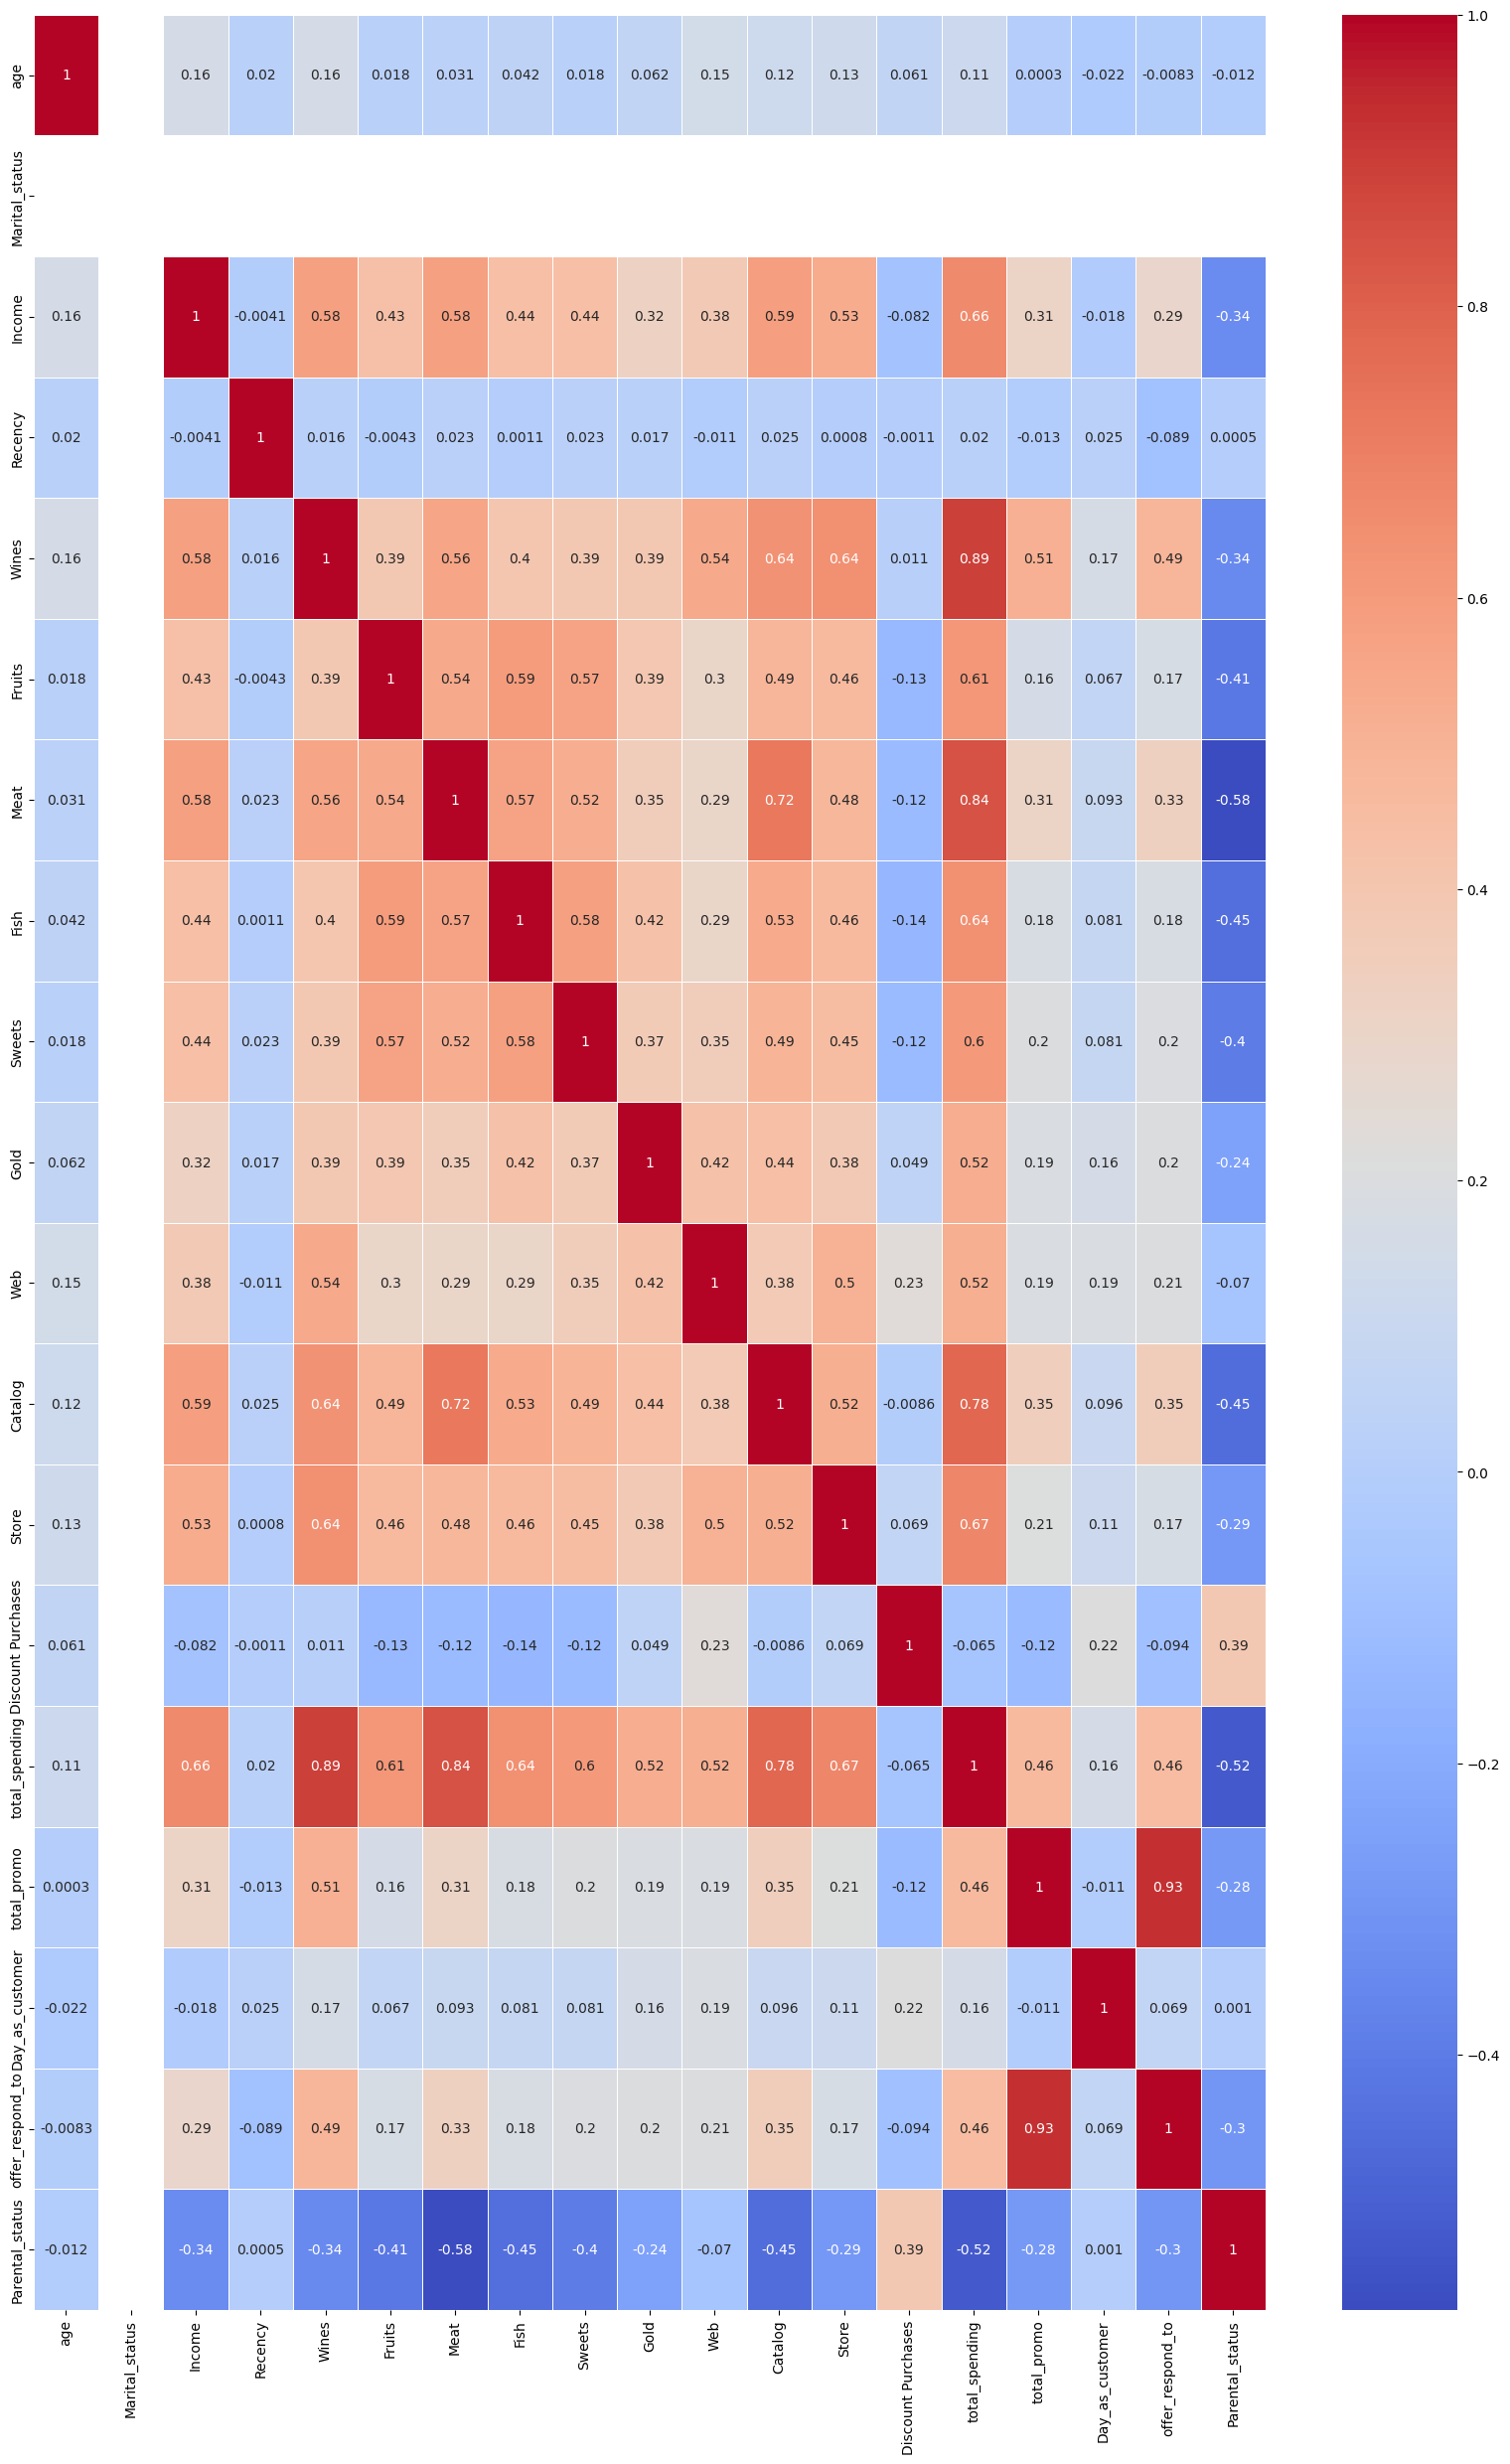

In [66]:
plt.figure(figsize=(20, 30))



sns.heatmap(df[num_features].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()

In [61]:
#TO CHECK NULL VALUES IN INCOME COLUMN
df.isnull().sum()


age                   0
Education             0
Marital_status        0
Income                0
Dt_Customer           0
Recency               0
Wines                 0
Fruits                0
Meat                  0
Fish                  0
Sweets                0
Gold                  0
Web                   0
Catalog               0
Store                 0
Discount Purchases    0
total_spending        0
total_promo           0
Day_as_customer       0
offer_respond_to      0
Parental_status       0
dtype: int64

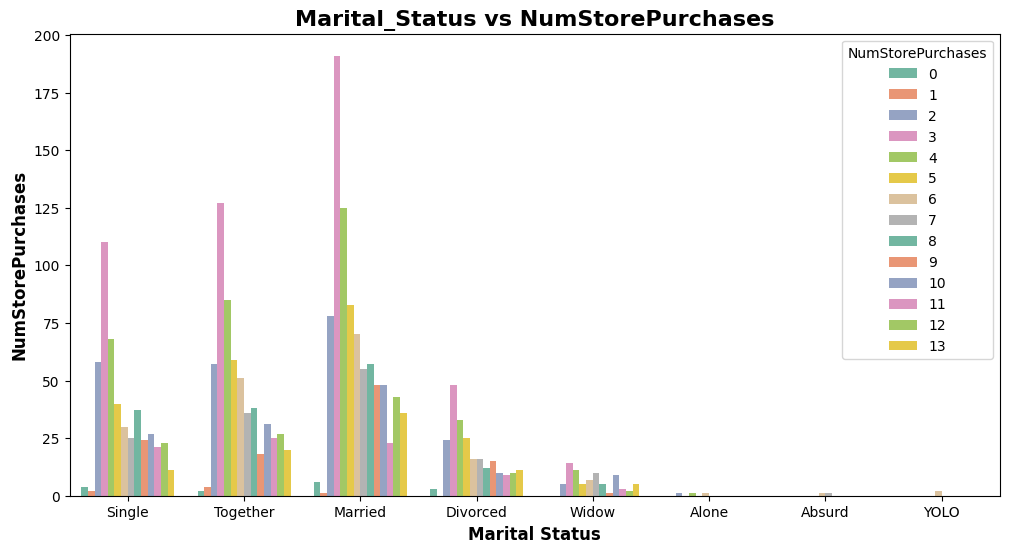

In [62]:
plt.figure(figsize=(12, 6))
sns.countplot(x="Marital_Status", data=df1, hue="NumStorePurchases", palette="Set2")
plt.title('Marital_Status vs NumStorePurchases', weight='bold', fontsize=16)
plt.xlabel('Marital Status', weight='bold', fontsize=12)
plt.ylabel('NumStorePurchases', weight='bold', fontsize=12)
plt.show()

In [63]:
data = []#tp calculate the ancient and the baby customer

for i in raw_df['Dt_Customer']:
    i = i.date()
    
    data.append(i)

print(f"the newest customer joined on {max(data)} and the oldest customer joined on {min(data)}")

the newest customer joined on 2014-06-29 and the oldest customer joined on 2012-07-30


In [64]:
df.head()

,age,Education,Marital_status,Income,Dt_Customer,Recency,Wines,Fruits,Meat,Fish,...,Gold,Web,Catalog,Store,Discount Purchases,total_spending,total_promo,Day_as_customer,offer_respond_to,Parental_status
0,69,Graduation,5,58138.0,2012-09-04,58,635,88,546,172,...,88,8,10,4,3,1617,0,4962,1,0
1,72,Graduation,5,46344.0,2014-03-08,38,11,1,6,2,...,6,1,1,2,2,27,0,4412,0,1
2,61,Graduation,5,71613.0,2013-08-21,26,426,49,127,111,...,42,8,2,10,1,776,0,4611,0,0
3,42,Graduation,5,26646.0,2014-02-10,26,11,4,20,10,...,5,2,0,4,2,53,0,4438,0,1
4,45,PhD,5,58293.0,2014-01-19,94,173,43,118,46,...,15,5,3,6,5,422,0,4460,0,1


In [67]:
sns.set_style("white")
sns.set(rc={"axes.facecolor":"#cce0ff","figure.facecolor":"#cce0ff"})
sns.set_context("poster",font_scale = .7)

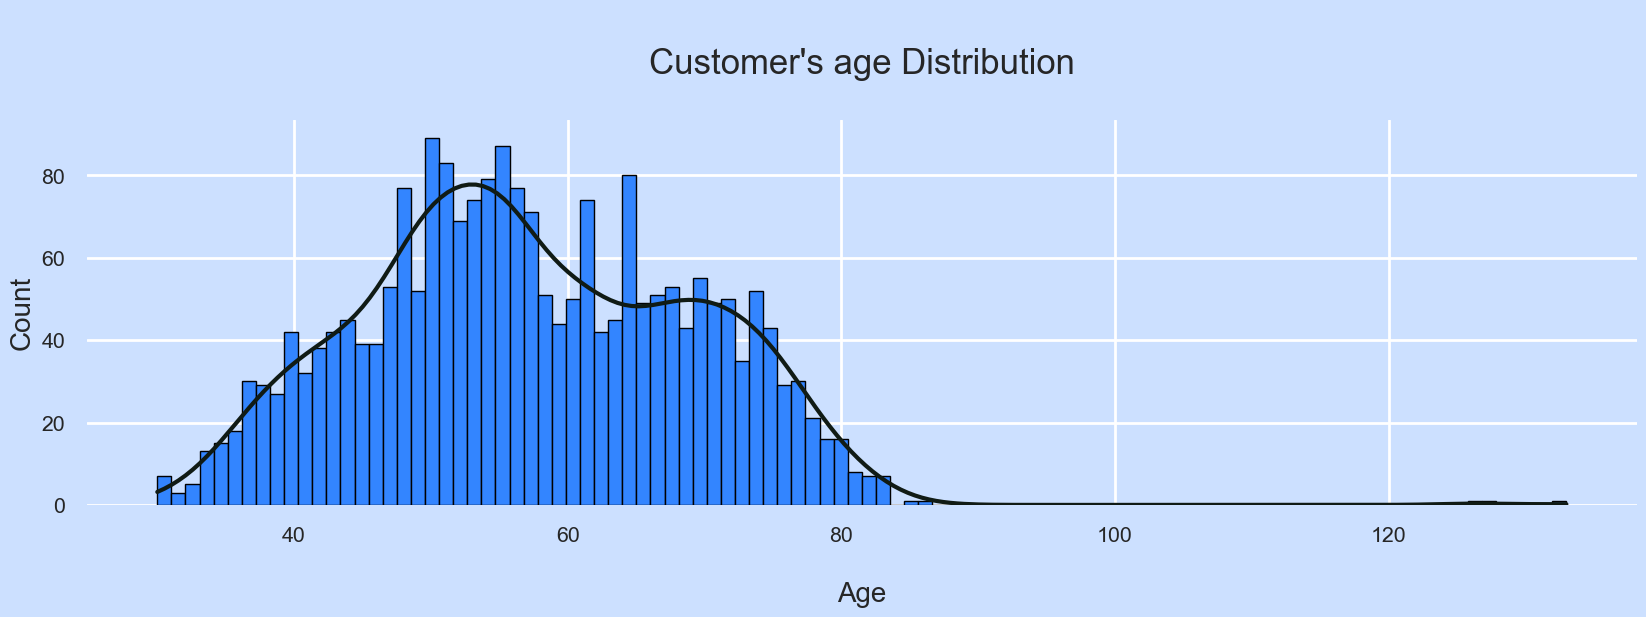

In [69]:
plt.subplots(figsize=(20, 5))
plt.title("Let's have a look on the distribution of customer's age :", weight="bold",fontsize=20, pad=20)

p = sns.histplot(df["age"],color="#3385ff",kde=True,bins=100,alpha=1,fill=True,edgecolor="black")
p.axes.lines[0].set_color("#101B15")
p.axes.set_title("\nCustomer's age Distribution\n",fontsize=25)
plt.ylabel("Count",fontsize=20)
plt.xlabel("\nAge",fontsize=20)
sns.despine(left=True, bottom=True)

plt.show()

Let's have a look again on the distribution of customer's age :


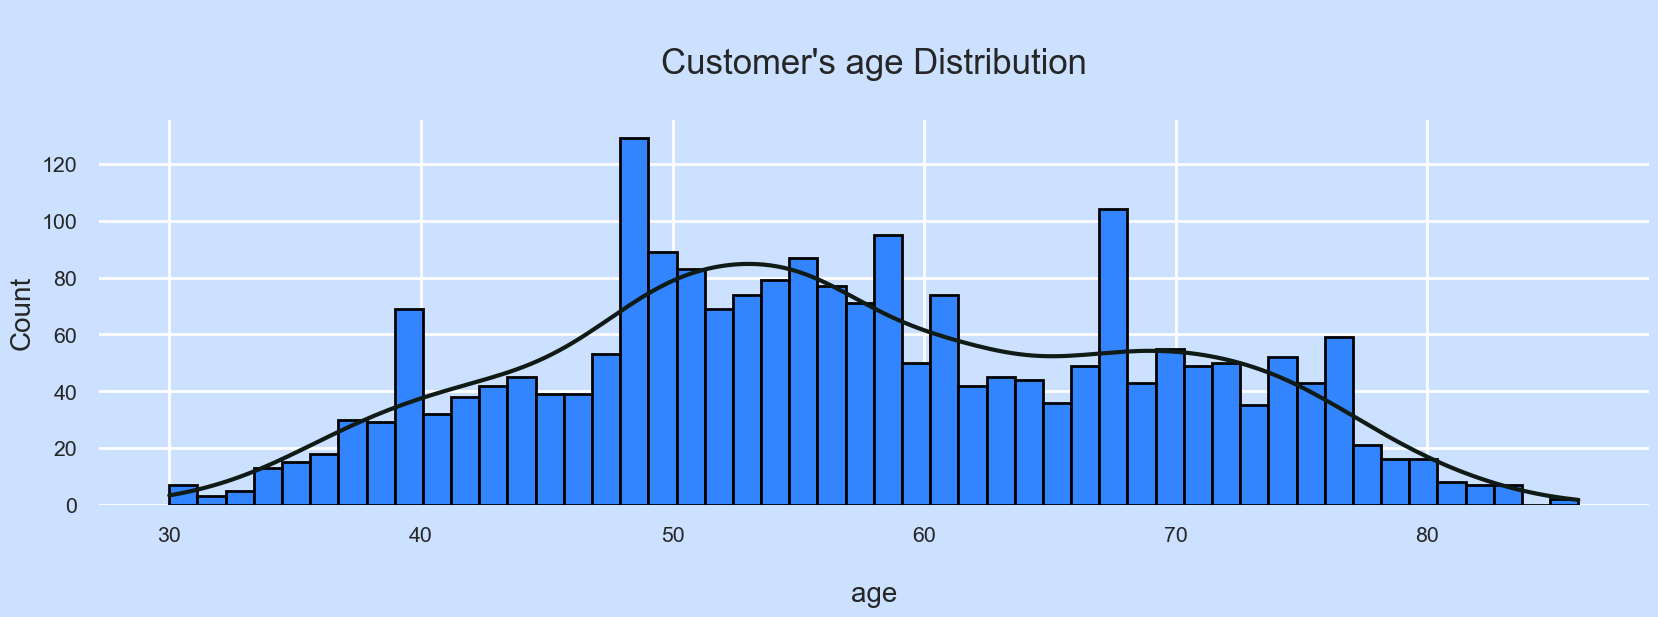

In [70]:
df = df[df["age"] < 90]#removing the outliers from age column as they are not real and they will affect our model performance

#let's plot now
print(f"Let's have a look again on the distribution of customer's age :")

plt.subplots(figsize=(20, 5))
p = sns.histplot(df["age"],color="#3385ff",kde=True,bins=50,alpha=1,fill=True,edgecolor="black")
p.axes.lines[0].set_color("#101B15")
p.axes.set_title("\nCustomer's age Distribution\n",fontsize=25)
plt.ylabel("Count",fontsize=20)
plt.xlabel("\nage",fontsize=20)
sns.despine(left=True, bottom=True)

plt.show()

**report**
* We can see it's a normal distribution of customer's age.
* Most of the customers are from 43 to 57.


Let's have a look on the customer's education :


KeyError: 0

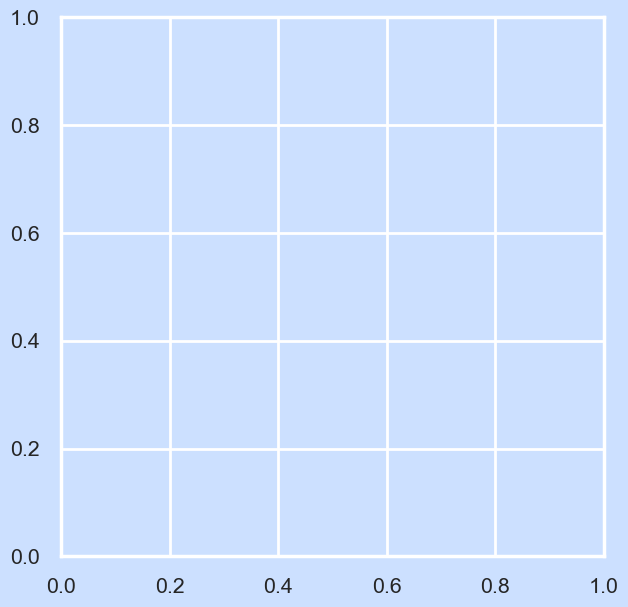

In [71]:
print(f"Let's have a look on the customer's education :")
plt.subplots(figsize=(7, 7))

labels = "Basic","2n Cycle", "Graduation", "Master", "PhD"
size = 0.5

wedges, texts, autotexts = plt.pie([df["Education"].value_counts()[0],
                                    df["Education"].value_counts()[1],
                                    df["Education"].value_counts()[2],
                                    df["Education"].value_counts()[3],
                                    df["Education"].value_counts()[4]],
                                    explode = (0,0,0,0,0),
                                    textprops=dict(size= 20, color= "white"),
                                    autopct="%.2f%%", 
                                    pctdistance = 0.72,
                                    radius=.9, 
                                    colors = ["#66ffff","#3385ff","#0099cc","#002080","#6600ff"],
                                    shadow = True,
                                    wedgeprops=dict(width = size, edgecolor = "black", 
                                    linewidth = 2),
                                    startangle = 20)

plt.legend(wedges, labels, title="Category",loc="center left",bbox_to_anchor=(1, 0, 0.5, 1), edgecolor = "black")
plt.title("\nCustomer's Education Level",fontsize=20)
plt.show()

Let's have a look on the distribution of customer's income and spending on basis of education level :


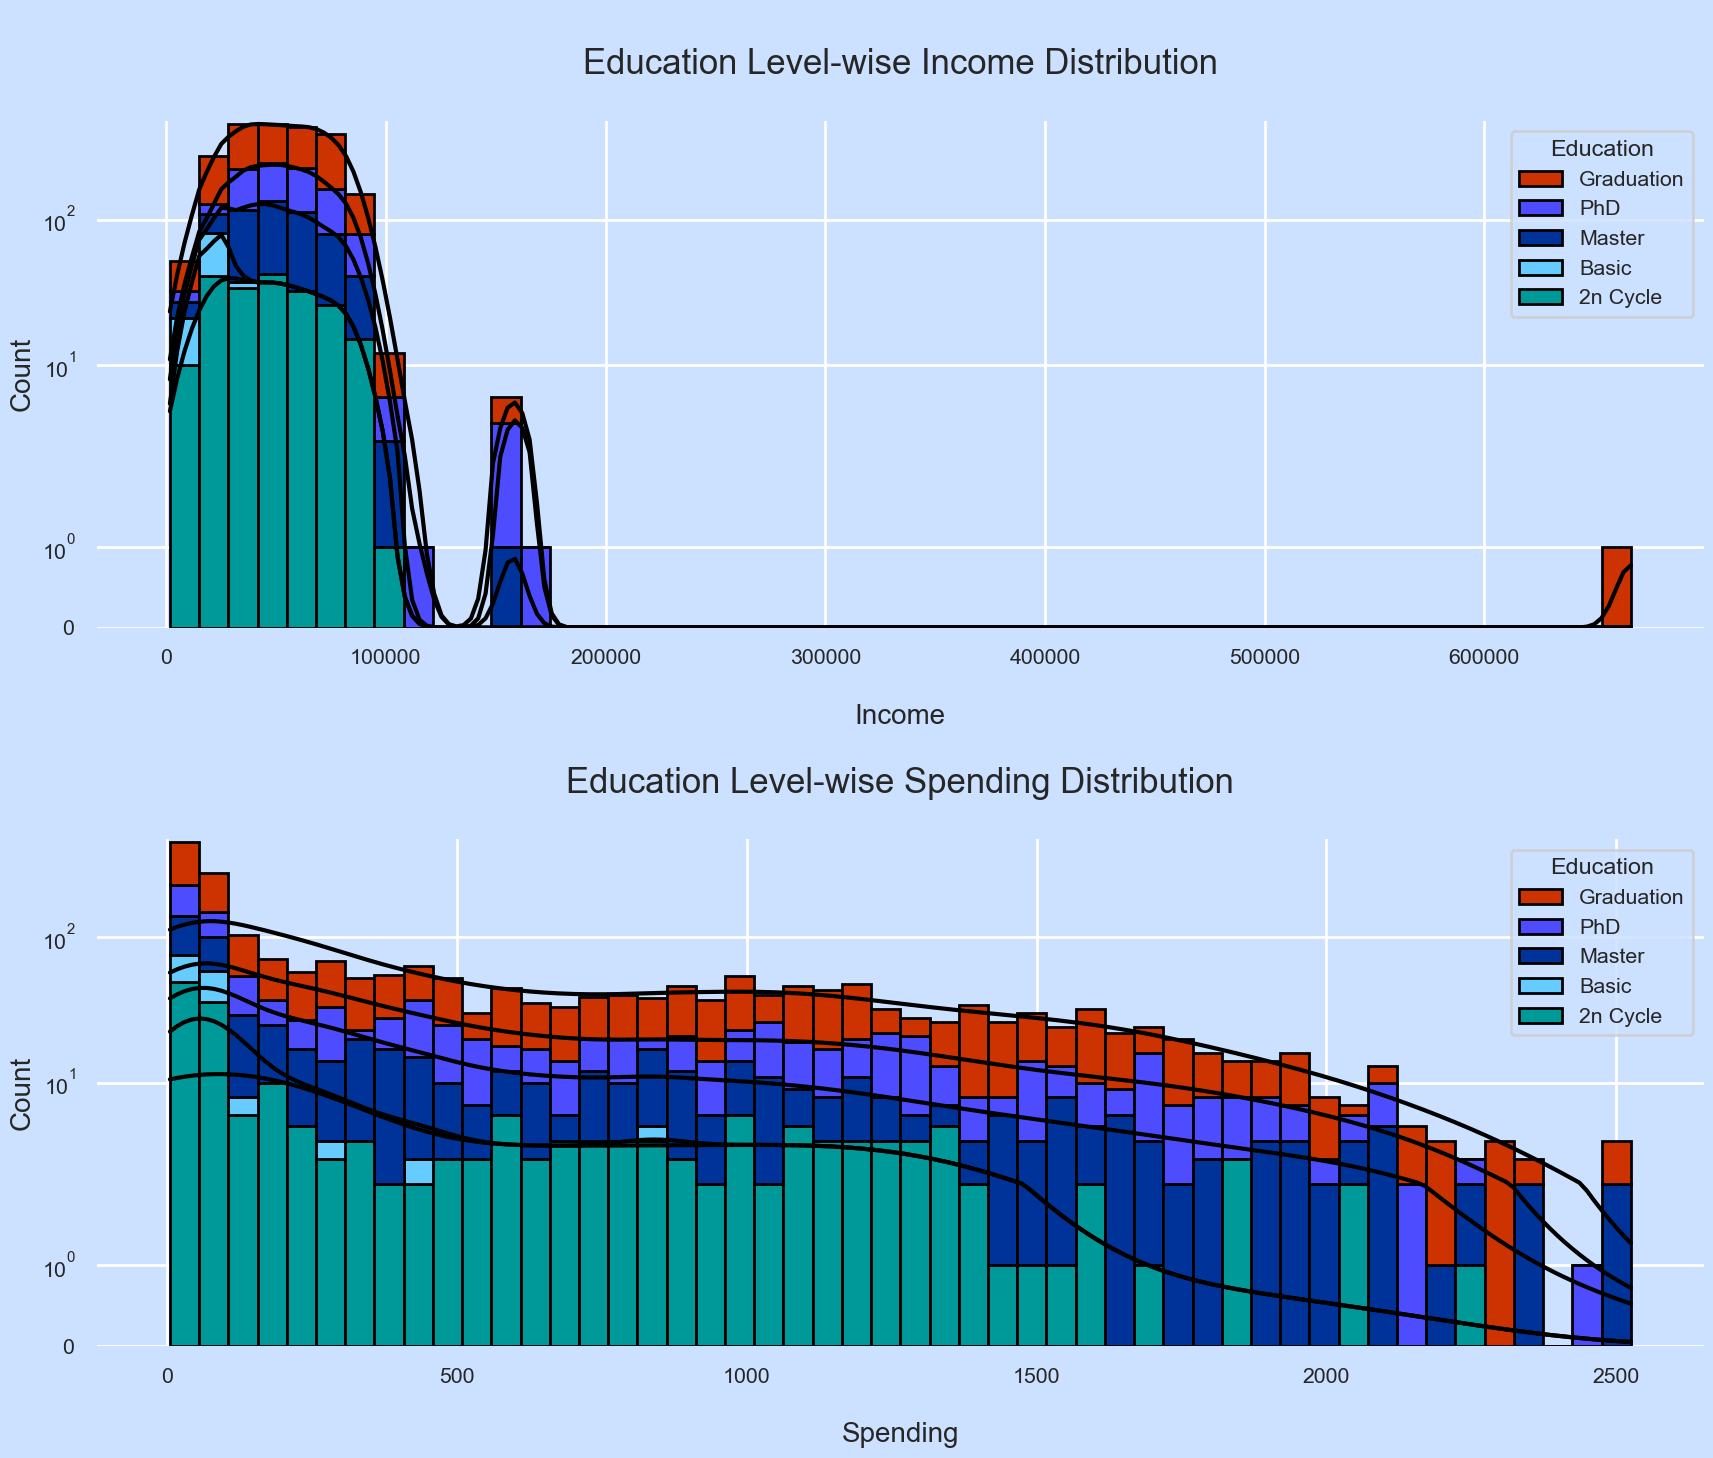

In [73]:
print(f"Let's have a look on the distribution of customer's income and spending on basis of education level :")

_, axes = plt.subplots(2,1,figsize=(20,16),sharex=False)
plt.tight_layout(pad=7.0)

colors = ["#cc2900","#0000ff","#66ffff", "#009999","#99ff66"]
colors2 = ["#cc3300","#4d4dff","#003399","#66ccff","#009999"]
sns.histplot(data=df,x="Income",hue="Education",multiple="stack",palette=colors2,ax=axes[0],kde=True,bins=50,alpha=1,fill=True,edgecolor="black")
axes[0].lines[0].set_color("000000")
axes[0].lines[1].set_color("000000")
axes[0].lines[2].set_color("000000")
axes[0].lines[3].set_color("000000")
axes[0].lines[4].set_color("000000")

axes[0].set_yscale("symlog")
axes[0].set_title("\nEducation Level-wise Income Distribution\n",fontsize=25)
axes[0].set_ylabel("Count",fontsize=20)
axes[0].set_xlabel("\nIncome",fontsize=20)

sns.histplot(data=df,x='total_spending',hue='Education',multiple="stack",palette=colors2,ax=axes[1],kde=True,bins=50,alpha=1,fill=True,edgecolor="black")
axes[1].lines[0].set_color("000000")
axes[1].lines[1].set_color("000000")
axes[1].lines[2].set_color("000000")
axes[1].lines[3].set_color("000000")
axes[1].lines[4].set_color("000000")
axes[1].set_yscale("symlog")
axes[1].set_title("\nEducation Level-wise Spending Distribution\n",fontsize=25)
axes[1].set_ylabel("Count",fontsize=20)
axes[1].set_xlabel("\nSpending",fontsize=20)

sns.despine(left=True, bottom=True)
plt.show()

#CUSTOMER CHILDERN COUNTS


Let's have a look on the distribution of customer's children :


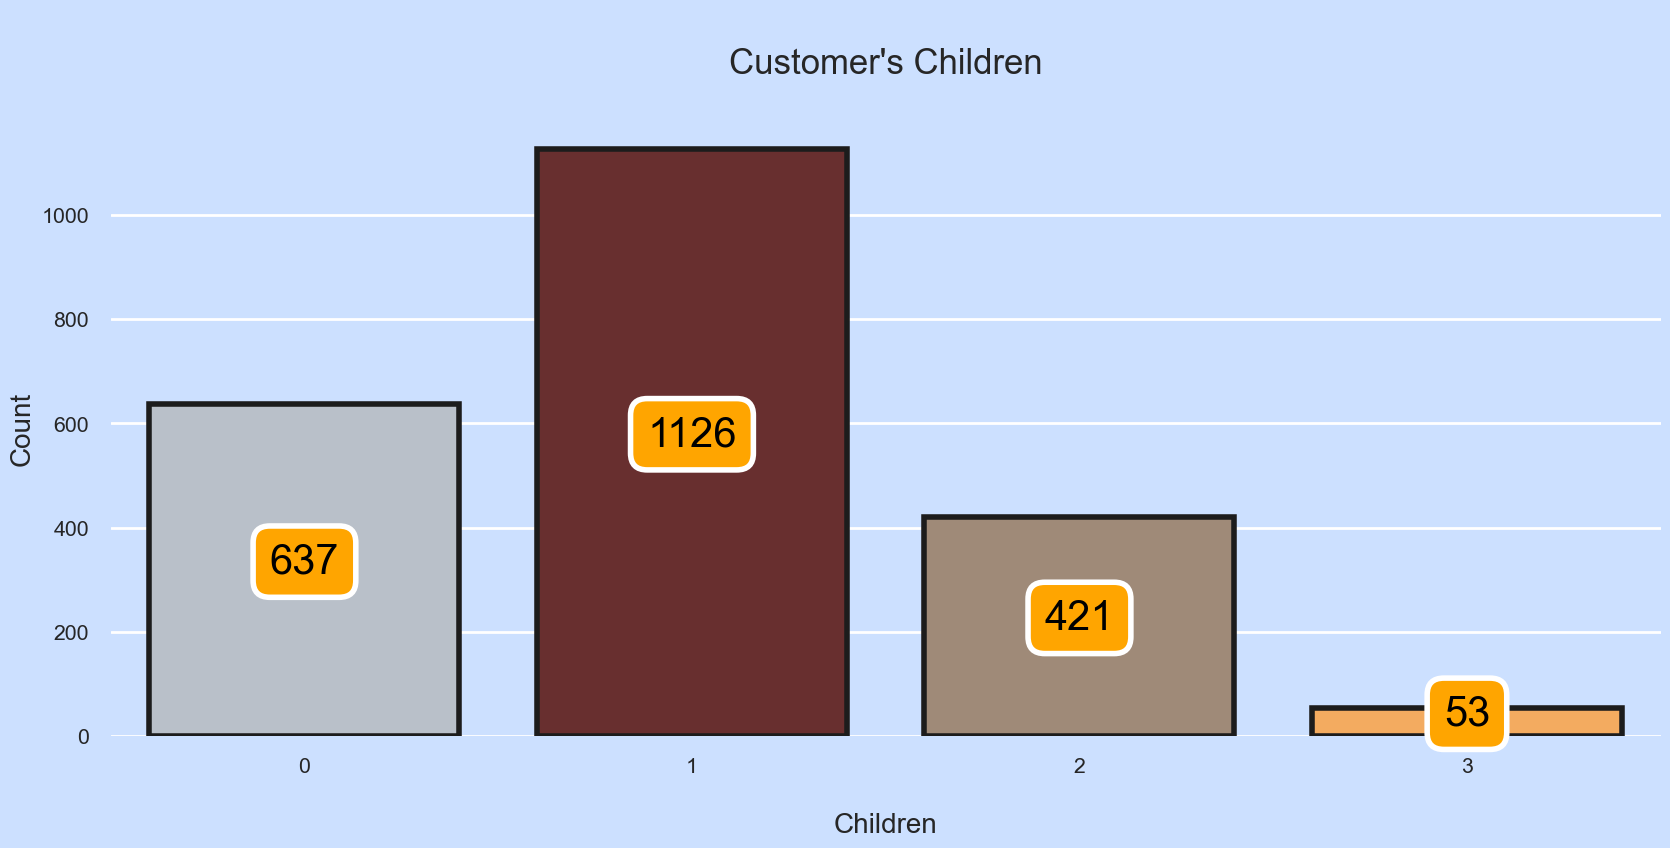

In [76]:
# create the children count from available household data
df['Children'] = raw_df.loc[df.index, 'Kidhome'] + raw_df.loc[df.index, 'Teenhome']

print("Let's have a look on the distribution of customer's children :")
plt.subplots(figsize=(20, 8))
p = sns.countplot(
    x=df["Children"],
    palette=["#B9C0C9", "#682F2F", "#9F8A78", "#F3AB60"],
    saturation=1,
    edgecolor="#1c1c1c",
    linewidth=4
)
p.axes.set_yscale("linear")
p.axes.set_title("\nCustomer's Children\n", fontsize=25)
p.axes.set_ylabel("Count", fontsize=20)
p.axes.set_xlabel("\nChildren", fontsize=20)
p.axes.set_xticklabels(p.get_xticklabels(), rotation=0)
for container in p.containers:
    p.bar_label(
        container,
        label_type="center",
        padding=6,
        size=30,
        color="black",
        rotation=0,
        bbox={"boxstyle": "round", "pad": 0.4, "facecolor": "orange", "edgecolor": "white", "linewidth": 4, "alpha": 1}
    )

sns.despine(left=True, bottom=True)
plt.show()